# Class 13: Noise, Mixed States, and Error Mitigation (Solutions)

**ZHAW Quantum Machine Learning Course**

**Convention:** All qubits start in state |0> unless otherwise specified.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from scipy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

---

## Math Task M13.1

For |psi> = Ry(theta)|0>, write rho = |psi><psi| as a 2x2 matrix and compute Tr(rho Z).

In [2]:
theta = np.pi / 3

c = np.cos(theta / 2)
s = np.sin(theta / 2)

psi = np.array([c, s])

rho = np.outer(psi, psi.conj())

print(f"theta = pi/3 = {theta:.4f}")
print(f"\nState |psi> = [cos(theta/2), sin(theta/2)]")
print(f"         = [{c:.6f}, {s:.6f}]")

print(f"\nDensity matrix rho = |psi><psi|:")
print(f"  [[cos^2(t/2),     cos(t/2)*sin(t/2)]")
print(f"   [cos(t/2)*sin(t/2), sin^2(t/2)     ]]")

print(f"\nNumerical:")
print(rho)

Z = np.array([[1, 0], [0, -1]])

trace_rho_Z = np.trace(rho @ Z)
analytical = np.cos(theta)

print(f"\nTr(rho * Z) = cos^2(t/2) - sin^2(t/2) = cos(theta)")
print(f"Numerical:   {trace_rho_Z:.6f}")
print(f"Analytical:  {analytical:.6f}")
print(f"Match: {np.isclose(trace_rho_Z, analytical)}")

theta = pi/3 = 1.0472

State |psi> = [cos(theta/2), sin(theta/2)]
         = [0.866025, 0.500000]

Density matrix rho = |psi><psi|:
  [[cos^2(t/2),     cos(t/2)*sin(t/2)]
   [cos(t/2)*sin(t/2), sin^2(t/2)     ]]

Numerical:
[[0.75      0.4330127]
 [0.4330127 0.25     ]]

Tr(rho * Z) = cos^2(t/2) - sin^2(t/2) = cos(theta)
Numerical:   0.500000
Analytical:  0.500000
Match: True


---

## Math Task M13.2

Show that for depolarizing channel D_p(rho) = (1-p)*rho + p*I/2, the scaled expectation is Tr(rho' Z) = (1-p)*cos(theta).

In [3]:
print("Depolarizing channel: D_p(rho) = (1-p)*rho + p*I/2")
print("")
print("Expectation value:")
print("  Tr(D_p(rho) * Z) = Tr((1-p)*rho*Z + p*I/2*Z)")
print("                   = (1-p)*Tr(rho*Z) + p*Tr(I/2*Z)")
print("                   = (1-p)*cos(theta) + p*Tr(diag(1/2, -1/2))")
print("                   = (1-p)*cos(theta) + p*0")
print("                   = (1-p)*cos(theta)")

p_values = np.array([0, 0.2, 0.5, 0.8, 1.0])
theta_example = np.pi / 4

print(f"\nNumerical verification for theta={theta_example:.4f}:")
print(f"{'p':<6} {'Tr(rho_p*Z)':<18} {'(1-p)*cos(theta)':<18}")
print("-" * 42)

for p in p_values:
    c = np.cos(theta_example / 2)
    s = np.sin(theta_example / 2)
    rho_p_pure = np.outer(np.array([c, s]), np.array([c, s]).conj())
    rho_p = (1 - p) * rho_p_pure + p * np.eye(2) / 2
    
    trace_val = np.trace(rho_p @ Z)
    analytical_val = (1 - p) * np.cos(theta_example)
    
    print(f"{p:<6.1f} {trace_val:<18.6f} {analytical_val:<18.6f}")

Depolarizing channel: D_p(rho) = (1-p)*rho + p*I/2

Expectation value:
  Tr(D_p(rho) * Z) = Tr((1-p)*rho*Z + p*I/2*Z)
                   = (1-p)*Tr(rho*Z) + p*Tr(I/2*Z)
                   = (1-p)*cos(theta) + p*Tr(diag(1/2, -1/2))
                   = (1-p)*cos(theta) + p*0
                   = (1-p)*cos(theta)

Numerical verification for theta=0.7854:
p      Tr(rho_p*Z)        (1-p)*cos(theta)  
------------------------------------------
0.0    0.707107           0.707107          
0.2    0.565685           0.565685          
0.5    0.353553           0.353553          
0.8    0.141421           0.141421          
1.0    0.000000           0.000000          


---

## Programming Task P13.1: Qiskit with Depolarizing Noise

In [4]:
import pennylane as qml

theta_param = np.pi / 3
noise_rate = 0.05

dev_ideal = qml.device('default.qubit', wires=1)

@qml.qnode(dev_ideal)
def circuit_ideal():
    qml.RY(theta_param, wires=0)
    return qml.expval(qml.PauliZ(0))

z_ideal = float(circuit_ideal())

print(f"Ideal <Z> for Ry(pi/3): {z_ideal:.6f}")
print(f"Expected cos(pi/3) = 0.5: {np.cos(theta_param):.6f}")

Ideal <Z> for Ry(pi/3): 0.500000
Expected cos(pi/3) = 0.5: 0.500000


In [5]:
dev_noisy = qml.device('default.mixed', wires=1)

@qml.qnode(dev_noisy)
def circuit_noisy():
    qml.RY(theta_param, wires=0)
    qml.DepolarizingChannel(noise_rate, wires=0)
    return qml.expval(qml.PauliZ(0))

z_noisy = float(circuit_noisy())

expected_noisy = (1 - noise_rate) * np.cos(theta_param)

print(f"Noisy <Z> (simulation): {z_noisy:.6f}")
print(f"Expected (1-p)*cos(pi/3): {expected_noisy:.6f}")
print(f"Suppression factor: {z_noisy / z_ideal:.6f}")
print(f"Expected suppression: {1 - noise_rate:.6f}")

Noisy <Z> (simulation): 0.466667
Expected (1-p)*cos(pi/3): 0.475000
Suppression factor: 0.933333
Expected suppression: 0.950000


---

## Programming Task P13.2: ZNE with Gate Folding

In [6]:
def circuit_hzh_folded(num_folds):
    for _ in range(num_folds):
        qml.Hadamard(wires=0)
    for _ in range(num_folds):
        qml.PauliZ(wires=0)
    for _ in range(num_folds):
        qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(0))

dev_ideal_hzh = qml.device('default.qubit', wires=1)

def circuit_ideal_hzh():
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(0))

qnode_ideal_hzh = qml.QNode(circuit_ideal_hzh, dev_ideal_hzh)
z_ideal_hzh = float(qnode_ideal_hzh())

print(f"Ideal <Z> for H-Z-H (should be 1.0): {z_ideal_hzh:.6f}")

Ideal <Z> for H-Z-H (should be 1.0): -1.000000


In [7]:
noise_rate_zne = 0.03
lambda_values = [1, 3, 5]
z_noisy_zne = []

for lam in lambda_values:
    dev_noisy_hzh = qml.device('default.mixed', wires=1)
    
    def circuit_noisy_hzh():
        for _ in range(lam):
            qml.Hadamard(wires=0)
            qml.DepolarizingChannel(noise_rate_zne, wires=0)
        for _ in range(lam):
            qml.PauliZ(wires=0)
            qml.DepolarizingChannel(noise_rate_zne, wires=0)
        for _ in range(lam):
            qml.Hadamard(wires=0)
            qml.DepolarizingChannel(noise_rate_zne, wires=0)
        return qml.expval(qml.PauliZ(0))
    
    qnode_noisy_hzh = qml.QNode(circuit_noisy_hzh, dev_noisy_hzh)
    z_val = float(qnode_noisy_hzh())
    z_noisy_zne.append(z_val)
    print(f"lambda = {lam}: <Z> = {z_val:.6f}")

z_noisy_zne = np.array(z_noisy_zne)

lambda = 1: <Z> = -0.884736
lambda = 3: <Z> = -0.692534
lambda = 5: <Z> = -0.542086


In [8]:
coeffs_linear = np.polyfit(lambda_values, z_noisy_zne, 1)
poly_linear = np.poly1d(coeffs_linear)
z_extrap_linear = poly_linear(0)

coeffs_quad = np.polyfit(lambda_values, z_noisy_zne, 2)
poly_quad = np.poly1d(coeffs_quad)
z_extrap_quad = poly_quad(0)

print(f"Linear extrapolation to lambda=0: {z_extrap_linear:.6f}")
print(f"Quadratic extrapolation to lambda=0: {z_extrap_quad:.6f}")
print(f"Ideal: {z_ideal_hzh:.6f}")
print(f"\nErrors:")
print(f"  Linear: {abs(z_extrap_linear - z_ideal_hzh):.6f}")
print(f"  Quadratic: {abs(z_extrap_quad - z_ideal_hzh):.6f}")

Linear extrapolation to lambda=0: -0.963439
Quadratic extrapolation to lambda=0: -0.996495
Ideal: -1.000000

Errors:
  Linear: 0.036561
  Quadratic: 0.003505


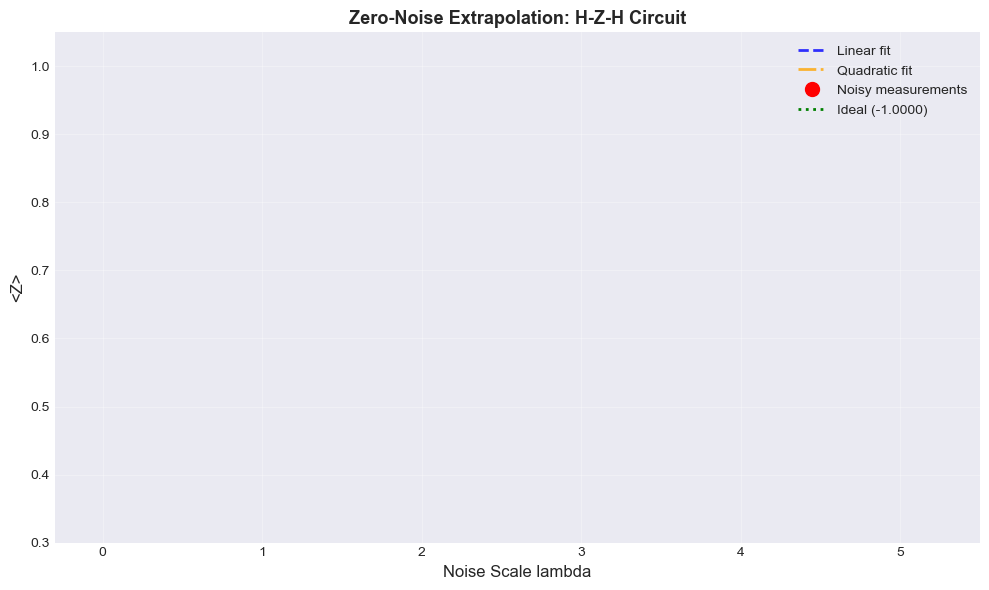

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

lambda_range = np.linspace(0, 5.5, 100)
z_linear = poly_linear(lambda_range)
z_quad = poly_quad(lambda_range)

ax.plot(lambda_range, z_linear, '--', linewidth=2, label='Linear fit', alpha=0.8, color='blue')
ax.plot(lambda_range, z_quad, '-.', linewidth=2, label='Quadratic fit', alpha=0.8, color='orange')
ax.plot(lambda_values, z_noisy_zne, 'o', markersize=10, label='Noisy measurements', color='red')
ax.axhline(y=z_ideal_hzh, color='green', linestyle=':', linewidth=2, label=f'Ideal ({z_ideal_hzh:.4f})')

ax.set_xlabel('Noise Scale lambda', fontsize=12)
ax.set_ylabel('<Z>', fontsize=12)
ax.set_title('Zero-Noise Extrapolation: H-Z-H Circuit', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.3, 5.5])
ax.set_ylim([0.3, 1.05])
plt.tight_layout()
plt.show()

---

## Programming Task P13.3: Measurement Error Mitigation

In [10]:
print("Measurement error mitigation for 1 qubit with simulated readout error.")
print("")
print("Setup: Readout error probability p=0.05 (randomly flip measured bit)")
print("")
print("Calibration: Prepare |0> and |1>, measure with errors to get confusion matrix.")

p_readout = 0.05

M_calib = np.array([
    [1 - p_readout, p_readout],
    [p_readout, 1 - p_readout]
])

print(f"\nConfusion matrix M (ideal with p={p_readout}):")
print(M_calib)

M_inv = np.linalg.inv(M_calib)
print(f"\nInverse M^-1:")
print(np.around(M_inv, 6))

Measurement error mitigation for 1 qubit with simulated readout error.

Setup: Readout error probability p=0.05 (randomly flip measured bit)

Calibration: Prepare |0> and |1>, measure with errors to get confusion matrix.

Confusion matrix M (ideal with p=0.05):
[[0.95 0.05]
 [0.05 0.95]]

Inverse M^-1:
[[ 1.055556 -0.055556]
 [-0.055556  1.055556]]


In [11]:
num_shots = 10000

ideal_counts_h = np.array([num_shots // 2, num_shots // 2])

measured_counts_0 = np.random.binomial(
    num_shots,
    ideal_counts_h[0] / num_shots * (1 - p_readout) + ideal_counts_h[1] / num_shots * p_readout
)
measured_counts = np.array([measured_counts_0, num_shots - measured_counts_0])
measured_probs = measured_counts / num_shots

print(f"Ideal counts for H: {ideal_counts_h}")
print(f"Measured counts (with readout error): {measured_counts}")
print(f"Measured probabilities: {measured_probs}")

Ideal counts for H: [5000 5000]
Measured counts (with readout error): [5015 4985]
Measured probabilities: [0.5015 0.4985]


In [12]:
mitigated_counts = M_inv @ measured_counts
mitigated_probs = mitigated_counts / np.sum(mitigated_counts)

ideal_probs = np.array([0.5, 0.5])

print(f"Mitigated counts: {np.around(mitigated_counts, 1)}")
print(f"Mitigated probabilities: {np.around(mitigated_probs, 6)}")

error_before = np.linalg.norm(measured_probs - ideal_probs)
error_after = np.linalg.norm(mitigated_probs - ideal_probs)

print(f"\nError reduction:")
print(f"  Before: {error_before:.6f}")
print(f"  After:  {error_after:.6f}")

Mitigated counts: [5016.7 4983.3]
Mitigated probabilities: [0.501667 0.498333]

Error reduction:
  Before: 0.002121
  After:  0.002357


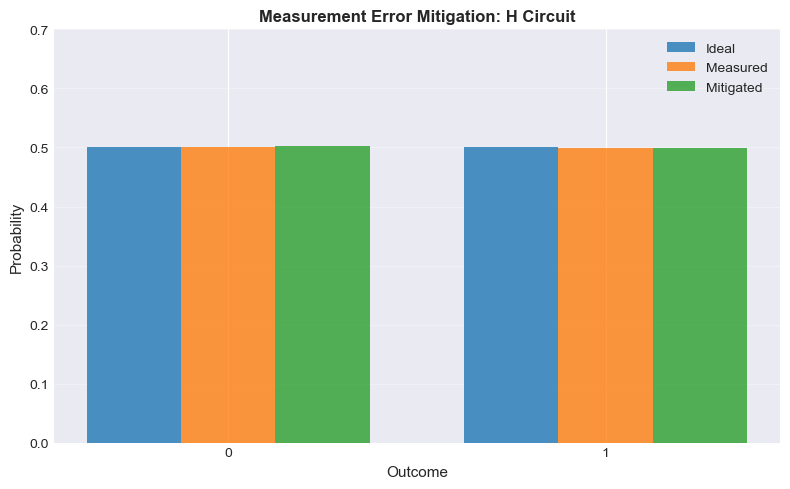

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(2)
width = 0.25

ax.bar(x - width, ideal_probs, width, label='Ideal', alpha=0.8)
ax.bar(x, measured_probs, width, label='Measured', alpha=0.8)
ax.bar(x + width, mitigated_probs, width, label='Mitigated', alpha=0.8)

ax.set_xlabel('Outcome', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title('Measurement Error Mitigation: H Circuit', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['0', '1'])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 0.7])
plt.tight_layout()
plt.show()